## Analyzing a real world data-set with SQL and Python

## Selected Socioeconomic Indicators in Chicago

### Connect to the database

In [1]:
import seaborn as sns
%load_ext sql

In [2]:
import csv, sqlite3

con = sqlite3.connect('socioeconomic.db')
cur = con.cursor()


In [3]:
%sql sqlite:///socioeconomic.db

## Store the dataset in a Table

In [4]:
import pandas as pd
df = pd.read_csv('https://data.cityofchicago.org/resource/jcxq-k9xf.csv')
df.to_sql('chicago_socioeconomic_data', con, if_exists='replace', index=False,method='multi')

78

In [5]:
# Import the 'prettytable' library, which is used to display data in a formatted table
import prettytable

# Set the default display format for prettytable to 'DEFAULT' (i.e., a simple table format)
prettytable.DEFAULT = 'DEFAULT'

### You can verify that the table creation was successful by making a basic query like:

In [6]:
%sql SELECT * FROM chicago_socioeconomic_data limit 5

 * sqlite:///socioeconomic.db
Done.


ca,community_area_name,percent_of_housing_crowded,percent_households_below_poverty,percent_aged_16_unemployed,percent_aged_25_without_high_school_diploma,percent_aged_under_18_or_over_64,per_capita_income_,hardship_index
1.0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0
2.0,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0
3.0,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0
4.0,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0
5.0,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0


In [8]:
%sql SELECT COUNT(*) FROM chicago_socioeconomic_data;

 * sqlite:///socioeconomic.db
Done.


COUNT(*)
78


In [9]:
%sql SELECT COUNT(*) FROM chicago_socioeconomic_data WHERE hardship_index > 50;

 * sqlite:///socioeconomic.db
Done.


COUNT(*)
38


In [10]:
%sql SELECT MAX(hardship_index) FROM chicago_socioeconomic_data;

 * sqlite:///socioeconomic.db
Done.


MAX(hardship_index)
98.0


In [13]:
%sql SELECT community_area_name FROM chicago_socioeconomic_data WHERE hardship_index = 98;

 * sqlite:///socioeconomic.db
Done.


community_area_name
Riverdale


2ND WAY

In [14]:
%sql SELECT community_area_name FROM chicago_socioeconomic_data ORDER BY hardship_index DESC LIMIT 1;

 * sqlite:///socioeconomic.db
Done.


community_area_name
Riverdale


3RD WAY

In [15]:
%sql SELECT community_area_name FROM chicago_socioeconomic_data WHERE hardship_index = (SELECT MAX(hardship_index) FROM chicago_socioeconomic_data)

 * sqlite:///socioeconomic.db
Done.


community_area_name
Riverdale


In [16]:
%sql SELECT community_area_name FROM chicago_socioeconomic_data WHERE per_capita_income_ > 60000;

 * sqlite:///socioeconomic.db
Done.


community_area_name
Lake View
Lincoln Park
Near North Side
Loop


 * sqlite:///socioeconomic.db
Done.


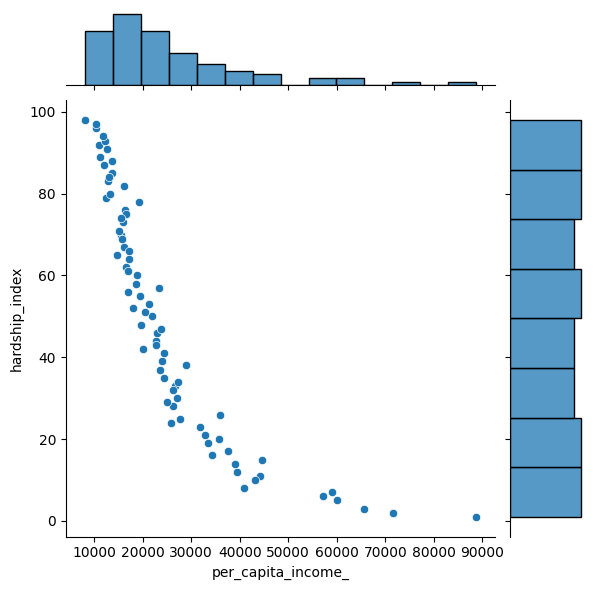

In [17]:
income_vs_hardship = %sql SELECT per_capita_income_, hardship_index FROM chicago_socioeconomic_data;
plot = sns.jointplot(x='per_capita_income_', y='hardship_index', data=income_vs_hardship.DataFrame())

You can see that as Per Capita Income rises as the Hardship Index decreases. We see that the points on the scatter plot are somewhat closer to a straight line in the negative direction, so we have a negative correlation between the two variables. 